# IEEE 57-Bus DC-OPF with Line Switching and Capacity Cuts
**Author:** Jewook Park  
**Date:** October 2025  
**Description:** DC-OPF with line switching and enhanced capacity constraints for IEEE 57-bus system


In [11]:
import os
os.environ["GRB_LICENSE_FILE"] = "/Users/a/Desktop/VIP/sc-opf/API key/gurobi.lic"
import re, pandas as pd, numpy as np, gurobipy as gp, matplotlib.pyplot as plt, networkx as nx
from gurobipy import GRB
pd.set_option('display.max_rows', 100)
print("Ready!")


Ready!


In [12]:
def extract_matrix_block(lines, varname):
    in_block, matrix_lines = False, []
    for line in lines:
        if line.strip().startswith(f"{varname} = ["): in_block = True; continue
        if in_block:
            if line.strip().startswith("];"): break
            clean = re.sub(r'%.*', '', line).strip().rstrip(';')
            if clean: matrix_lines.append(clean)
    return np.array([[float(x) for x in line.split()] for line in matrix_lines])

with open('data/pglib_opf_case57_ieee.m', 'r') as f: lines = f.readlines()
bus_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.bus'), columns=['bus_i','type','Pd','Qd','Gs','Bs','area','Vm','Va','baseKV','zone','Vmax','Vmin'])
gen_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.gen'), columns=['bus','Pg','Qg','Qmax','Qmin','Vg','mBase','status','Pmax','Pmin'])
branch_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.branch'), columns=['fbus','tbus','r','x','b','rateA','rateB','rateC','ratio','angle','status','angmin','angmax'])
gencost_df = pd.DataFrame(extract_matrix_block(lines, 'mpc.gencost'), columns=['model','startup','shutdown','n','c2','c1','c0'])
print(f"Loaded: {len(bus_df)} buses, {len(branch_df)} branches")


Loaded: 57 buses, 80 branches


In [13]:
# Proper comparison: Run models separately for each configuration

def solve_with_switching(bus_df, gen_df, branch_df, gencost_df, allow_switching=True, load_factor=1.0, capacity_factor=0.9):
    """Solve DC-OPF with or without switching"""
    model = gp.Model("DC-OPF")
    model.Params.OutputFlag = 0
    ref_bus = bus_df[bus_df['type'] == 3]['bus_i'].values[0]
    M = 1000
    
    # Scale load
    bus_df_scaled = bus_df.copy()
    bus_df_scaled['Pd'] = bus_df_scaled['Pd'] * load_factor
    
    Pg = model.addVars(gen_df.index, lb=0, name="Pg")
    theta = model.addVars(bus_df_scaled['bus_i'], lb=-GRB.INFINITY, name="theta")
    P_branch = model.addVars(branch_df.index, lb=-GRB.INFINITY, name="P_branch")
    
    if allow_switching:
        z = model.addVars(branch_df.index, vtype=GRB.BINARY, name="z")
    else:
        z = model.addVars(branch_df.index, lb=1, ub=1, name="z")  # Force all lines ON
    
    obj = gp.QuadExpr()
    for idx, row in gencost_df.iterrows():
        obj += row['c2'] * Pg[idx]*Pg[idx] + row['c1'] * Pg[idx] + row['c0']
    model.setObjective(obj, GRB.MINIMIZE)
    
    model.addConstr(theta[ref_bus] == 0)
    
    for idx, row in gen_df.iterrows():
        model.addConstr(Pg[idx] >= row['Pmin'])
        model.addConstr(Pg[idx] <= row['Pmax'])
    
    for idx, row in branch_df.iterrows():
        fbus, tbus, x = row['fbus'], row['tbus'], row['x']
        B = 1.0 / x
        model.addConstr(P_branch[idx] - B * (theta[fbus] - theta[tbus]) <= M * (1 - z[idx]))
        model.addConstr(P_branch[idx] - B * (theta[fbus] - theta[tbus]) >= -M * (1 - z[idx]))
        model.addConstr(P_branch[idx] <= M * z[idx])
        model.addConstr(P_branch[idx] >= -M * z[idx])
    
    for idx, row in branch_df.iterrows():
        rateA = row['rateA'] * capacity_factor
        if row['rateA'] > 0:
            model.addConstr(P_branch[idx] <= rateA * z[idx])
            model.addConstr(P_branch[idx] >= -rateA * z[idx])
    
    for idx, row in bus_df_scaled.iterrows():
        bus, Pd = row['bus_i'], row['Pd']
        gen_at_bus = gen_df[gen_df['bus'] == bus].index.tolist()
        gen_P = gp.quicksum(Pg[g] for g in gen_at_bus) if gen_at_bus else 0
        branch_out = gp.quicksum(P_branch[br] for br in branch_df[branch_df['fbus'] == bus].index)
        branch_in = gp.quicksum(P_branch[br] for br in branch_df[branch_df['tbus'] == bus].index)
        model.addConstr(gen_P - Pd == branch_out - branch_in)
    
    model.optimize()
    return model, Pg, theta, P_branch, z, bus_df_scaled

# Solve only 1.05x Load configurations
print("Solving 1.05x Load configurations...")

print("1. 1.05x Load - No Switching")
model_nosw_105, Pg_nosw_105, theta_nosw_105, Pbr_nosw_105, z_nosw_105, bus_nosw_105 = solve_with_switching(
    bus_df, gen_df, branch_df, gencost_df, allow_switching=False, load_factor=1.05)

print("2. 1.05x Load - With Switching")
model_sw_105, Pg_sw_105, theta_sw_105, Pbr_sw_105, z_sw_105, bus_sw_105 = solve_with_switching(
    bus_df, gen_df, branch_df, gencost_df, allow_switching=True, load_factor=1.05)

# Print results
print("\n" + "="*70)
print("COMPARISON RESULTS - 1.05x Load")
print("="*70)

if model_nosw_105.status == GRB.OPTIMAL:
    lines_on = sum(z_nosw_105[i].X > 0.5 for i in branch_df.index)
    print(f"\n1.05x Load - No Switching:")
    print(f"  Cost: ${model_nosw_105.objVal:.2f}")
    print(f"  Lines ON: {lines_on}/{len(branch_df)}")
else:
    print(f"\n1.05x Load - No Switching: FAILED (status {model_nosw_105.status})")

if model_sw_105.status == GRB.OPTIMAL:
    lines_on = sum(z_sw_105[i].X > 0.5 for i in branch_df.index)
    print(f"\n1.05x Load - With Switching:")
    print(f"  Cost: ${model_sw_105.objVal:.2f}")
    print(f"  Lines ON: {lines_on}/{len(branch_df)}")
else:
    print(f"\n1.05x Load - With Switching: FAILED (status {model_sw_105.status})")

# Cost savings
if model_nosw_105.status == GRB.OPTIMAL and model_sw_105.status == GRB.OPTIMAL:
    savings_105 = model_nosw_105.objVal - model_sw_105.objVal
    savings_pct_105 = (savings_105 / model_nosw_105.objVal) * 100
    print(f"\n💰 Cost Savings with Switching: ${savings_105:.2f} ({savings_pct_105:.2f}%)")
print("="*70)


Solving 1.05x Load configurations...
1. 1.05x Load - No Switching
2. 1.05x Load - With Switching



COMPARISON RESULTS - 1.05x Load

1.05x Load - No Switching:
  Cost: $37135.44
  Lines ON: 80/80

1.05x Load - With Switching:
  Cost: $36696.40
  Lines ON: 63/80

💰 Cost Savings with Switching: $439.04 (1.18%)



📊 Visualizing configurations...
1. No Switching at 1.05x Load


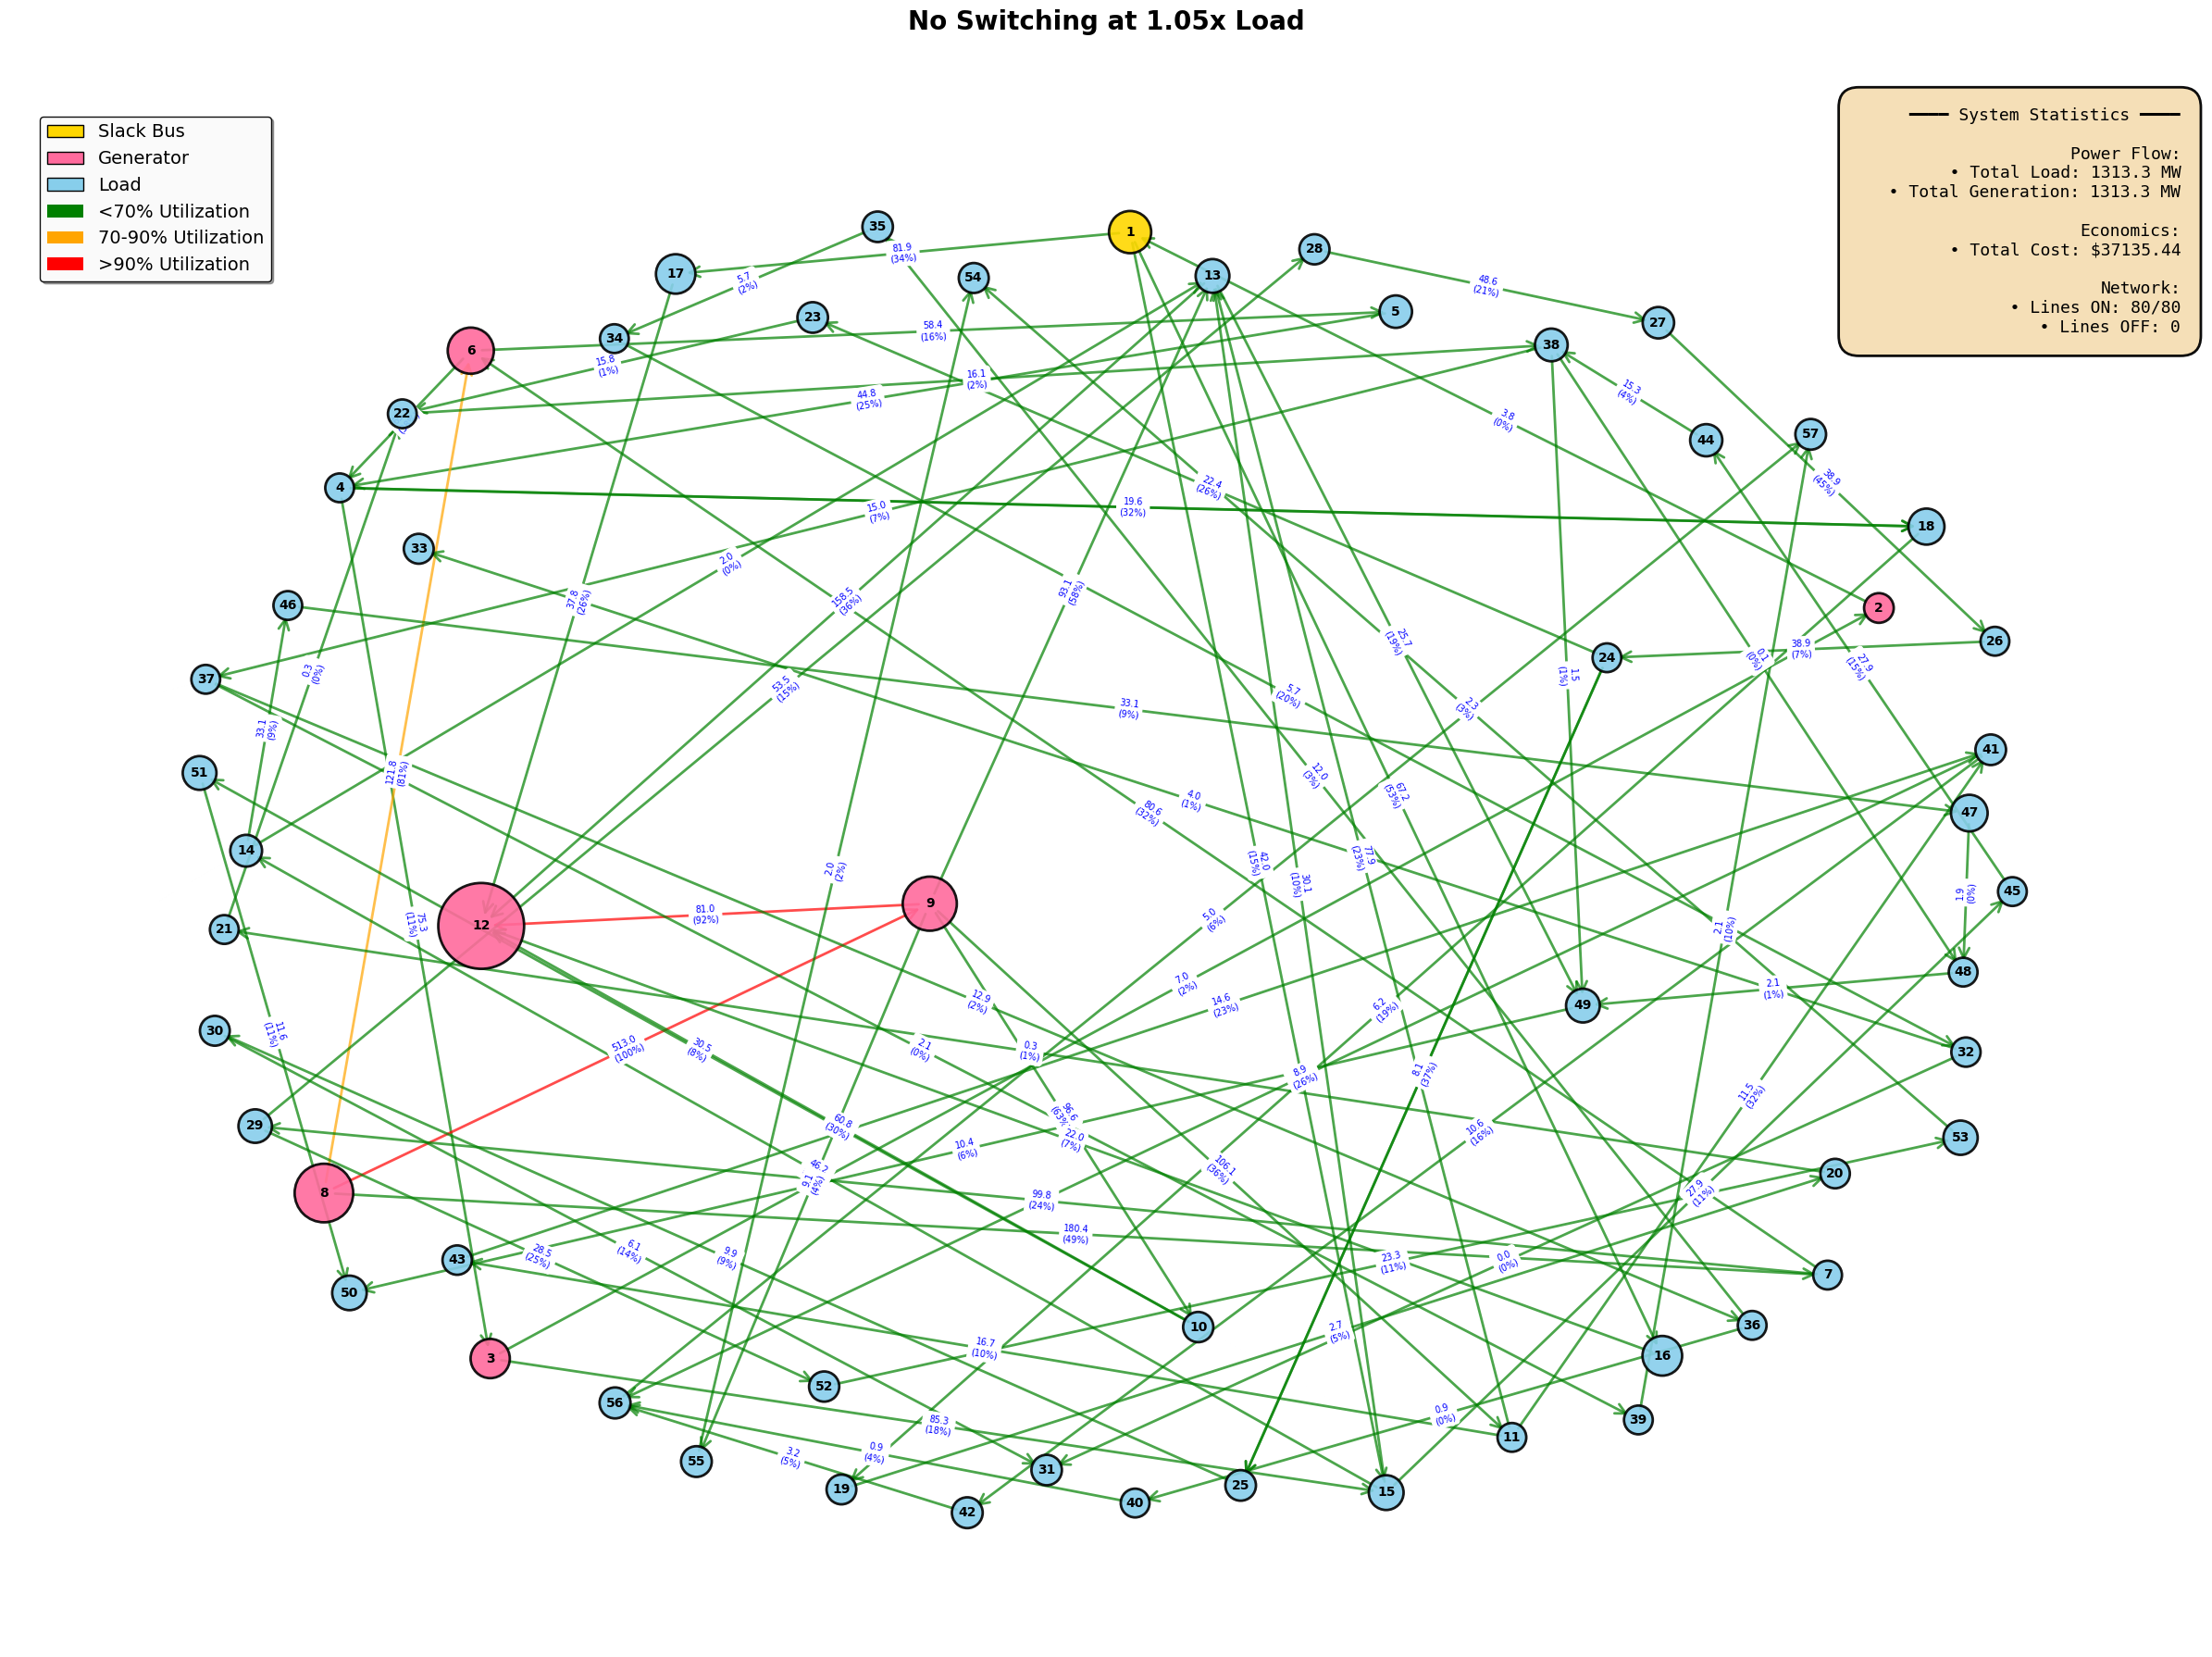

2. With Switching at 1.05x Load


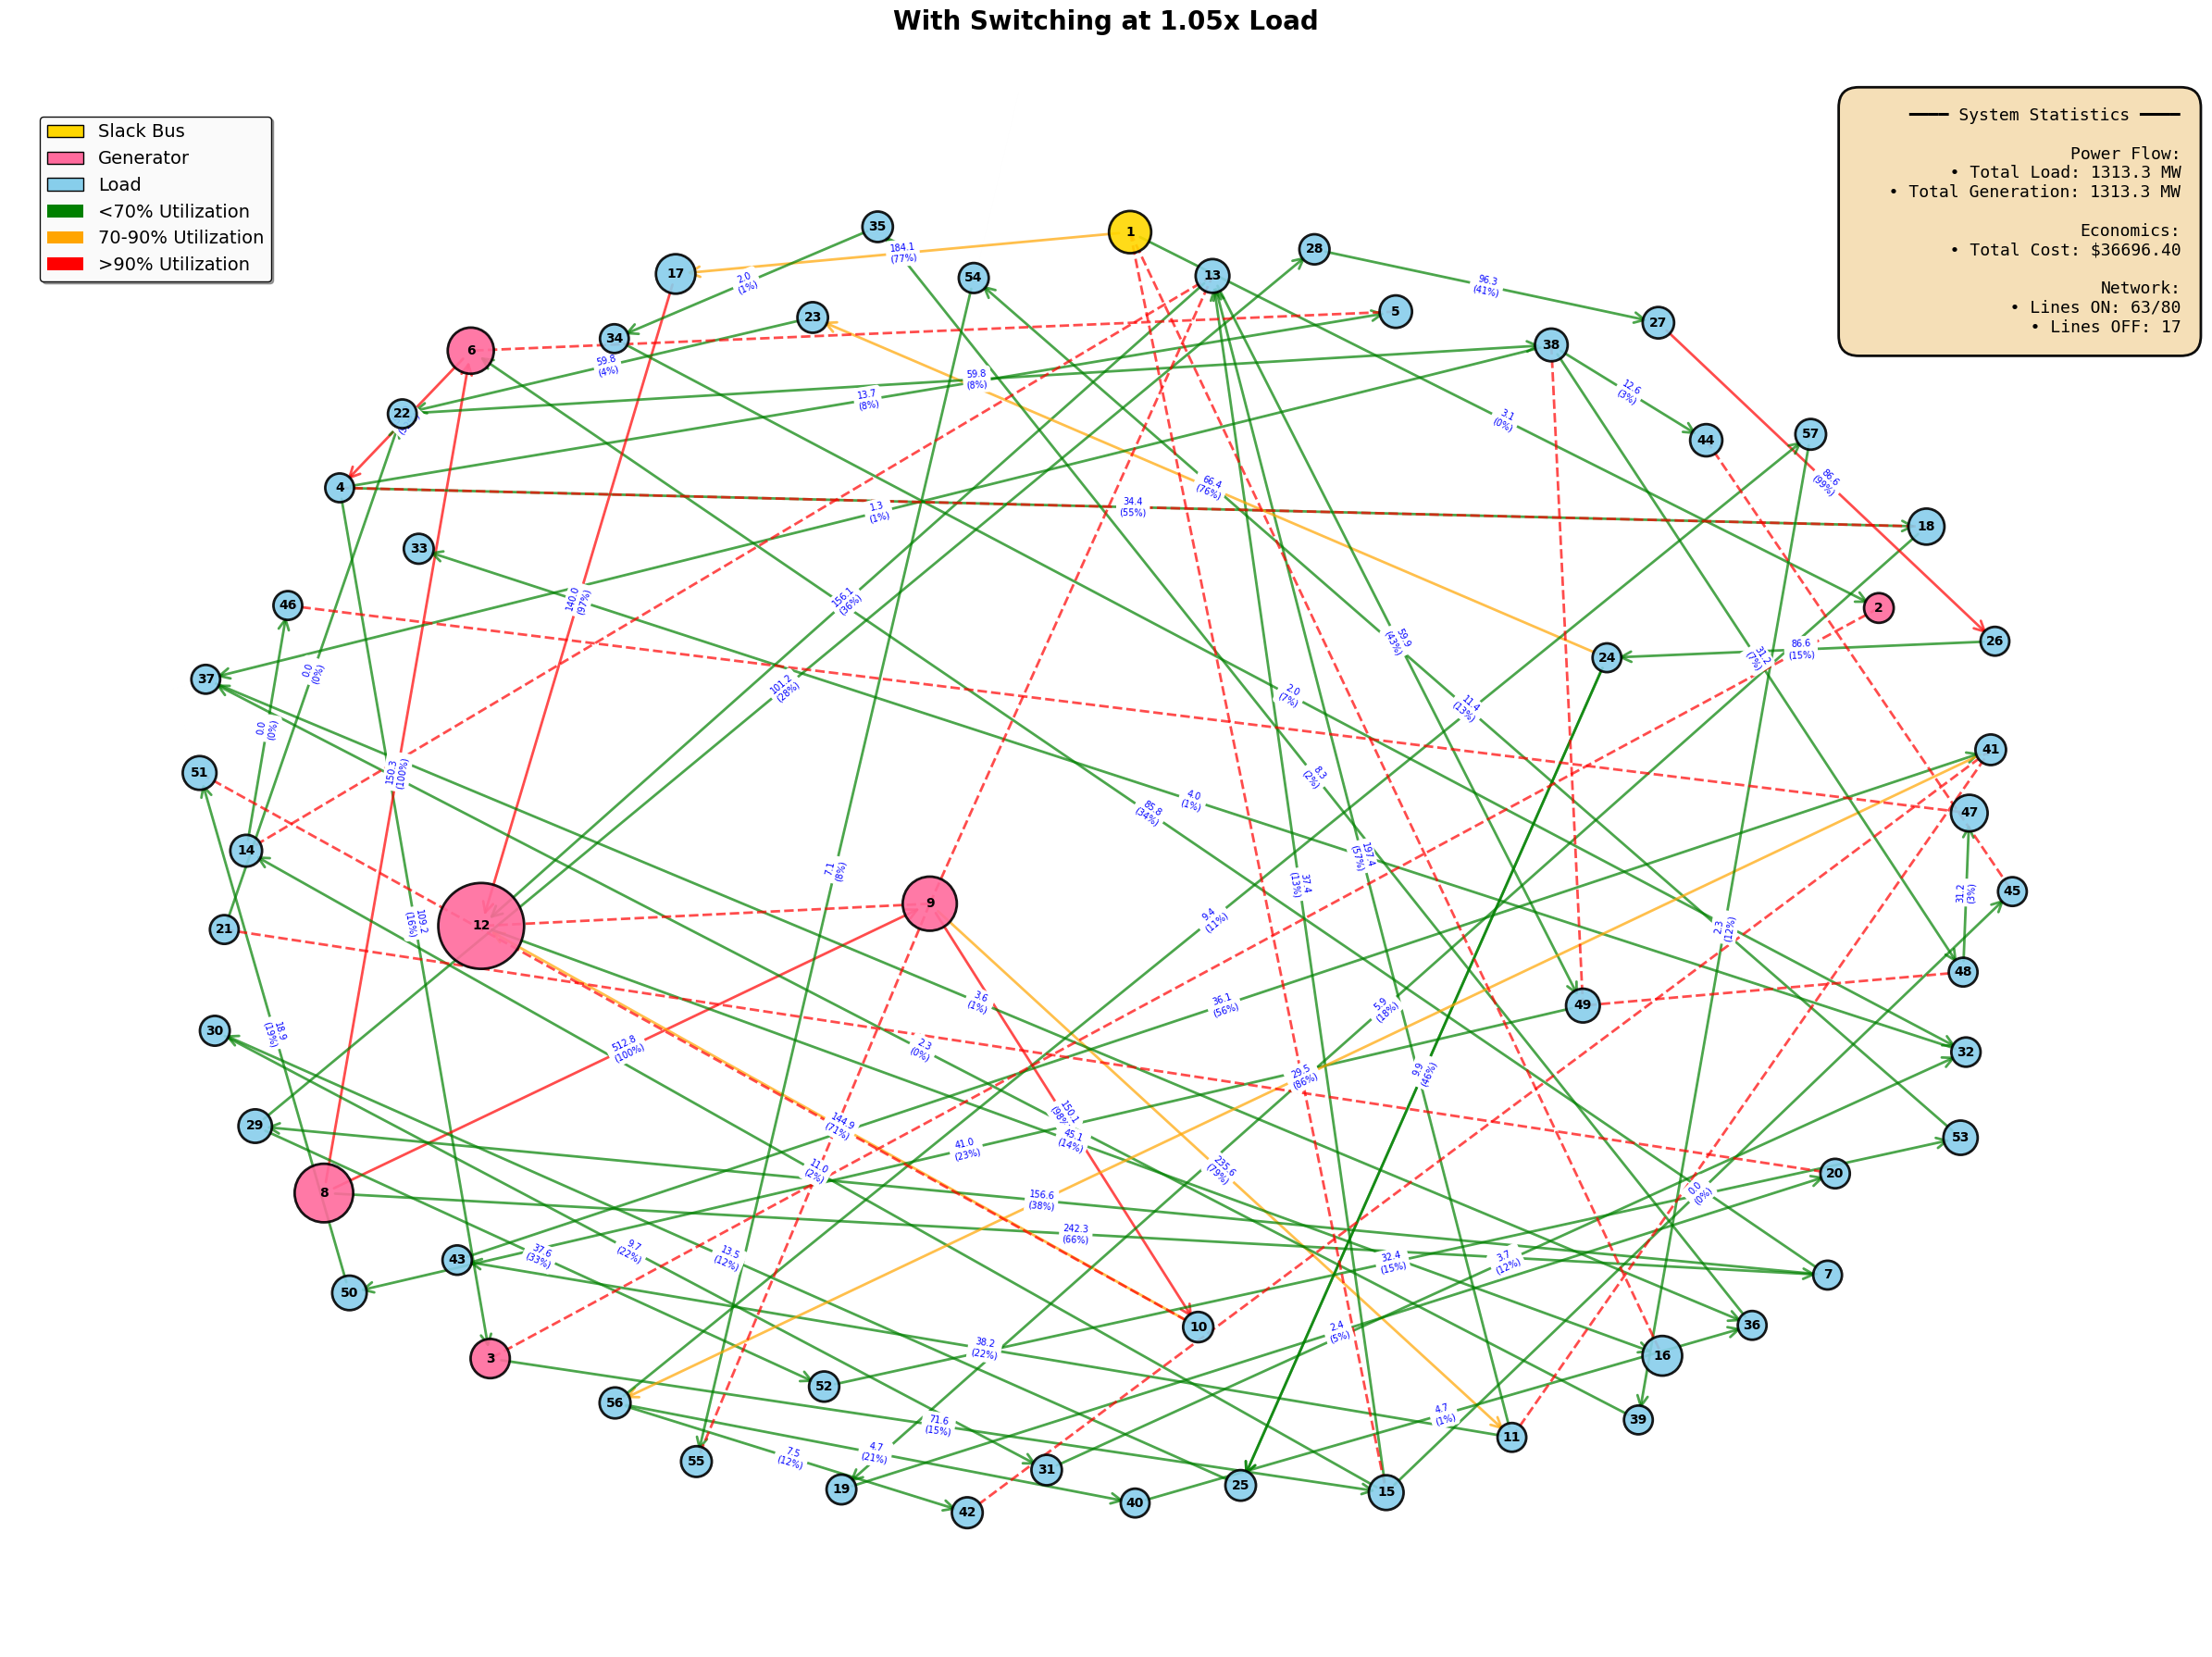

In [14]:
# Visualize 1.05x Load comparison with directional arrows and edge labels (separately)

def visualize_single_config(title, mdl, z_var, P_var, bus_data):
    """Visualize a single configuration with proper costs, flow directions, and edge labels"""
    fig, ax = plt.subplots(1, 1, figsize=(24, 18))  # Full size for one plot
    
    for (_, mdl, z_var, P_var, bus_data) in [(title, mdl, z_var, P_var, bus_data)]:
        if mdl.status != GRB.OPTIMAL:
            ax.text(0.5, 0.5, f"{title}\nFAILED", ha='center', va='center', fontsize=16)
            ax.axis('off')
            continue
            
        G = nx.DiGraph()  # Use DiGraph for directed edges
        for _, row in bus_data.iterrows():
            G.add_node(int(row['bus_i']), load=row['Pd'], bus_type=row['type'])
        
        edges_on, edges_off = [], []
        edge_labels = {}
        
        for idx, row in branch_df.iterrows():
            fbus, tbus = int(row['fbus']), int(row['tbus'])
            flow = P_var[idx].X
            capacity = row['rateA'] * 0.9  # capacity_factor = 0.9
            
            if z_var[idx].X < 0.5:
                edges_off.append((fbus, tbus))
            else:
                # Add edge in flow direction
                flow_abs = abs(flow)
                utilization = (flow_abs / capacity * 100) if capacity > 0 else 0
                
                if flow >= 0:
                    edges_on.append((fbus, tbus))
                    edge_labels[(fbus, tbus)] = f"{flow_abs:.1f}\n({utilization:.0f}%)"
                else:
                    edges_on.append((tbus, fbus))
                    edge_labels[(tbus, fbus)] = f"{flow_abs:.1f}\n({utilization:.0f}%)"
            G.add_edge(fbus, tbus)
        
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        gen_buses = set(gen_df['bus'].astype(int))
        slack = int(bus_df[bus_df['type'] == 3]['bus_i'].values[0])
        node_colors = ['gold' if n==slack else '#FF6B9D' if n in gen_buses else 'skyblue' for n in G.nodes]
        node_sizes = [500 + G.nodes[n]['load']*10 for n in G.nodes]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, linewidths=2, edgecolors='black', ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
        
        if edges_on:
            # Color edges by utilization
            edge_colors_list = []
            for edge in edges_on:
                # Find utilization from edge labels
                label = edge_labels.get(edge, "")
                if label:
                    util = float(label.split('(')[1].split('%')[0])
                    if util > 90:
                        edge_colors_list.append('red')
                    elif util > 70:
                        edge_colors_list.append('orange')
                    else:
                        edge_colors_list.append('green')
                else:
                    edge_colors_list.append('gray')
            
            nx.draw_networkx_edges(G, pos, edgelist=edges_on, edge_color=edge_colors_list, width=2, alpha=0.7, 
                                  arrows=True, arrowsize=20, arrowstyle='->', ax=ax)
        if edges_off:
            nx.draw_networkx_edges(G, pos, edgelist=edges_off, edge_color='red', width=2, alpha=0.7, 
                                  style='dashed', arrows=False, ax=ax)
        
        # Draw edge labels
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, font_color='blue', ax=ax)
        
        # Legend
        from matplotlib.patches import Patch
        legend_handles = [
            Patch(facecolor='gold', edgecolor='black', label='Slack Bus'),
            Patch(facecolor='#FF6B9D', edgecolor='black', label='Generator'),
            Patch(facecolor='skyblue', edgecolor='black', label='Load'),
            Patch(facecolor='green', label='<70% Utilization'),
            Patch(facecolor='orange', label='70-90% Utilization'),
            Patch(facecolor='red', label='>90% Utilization')
        ]
        ax.legend(handles=legend_handles, loc='upper left', fontsize=14, framealpha=0.95,
                 edgecolor='black', fancybox=True, shadow=True, frameon=True,
                 bbox_to_anchor=(0.01, 0.99))
        
        lines_on = sum(z_var[i].X > 0.5 for i in branch_df.index)
        lines_off = len(branch_df) - lines_on
        total_gen = sum(Pg_sw_105[i].X for i in gen_df.index) if 'Switching' in title else sum(Pg_nosw_105[i].X for i in gen_df.index)
        total_load = bus_data['Pd'].sum()
        
        stats = f"""━━━━ System Statistics ━━━━

Power Flow:
   • Total Load: {total_load:.1f} MW
   • Total Generation: {total_gen:.1f} MW

Economics:
   • Total Cost: ${mdl.objVal:.2f}

Network:
   • Lines ON: {lines_on}/{len(branch_df)}
   • Lines OFF: {lines_off}"""
        
        ax.text(0.99, 0.99, stats, transform=ax.transAxes, fontsize=13, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=1.2', facecolor='wheat', alpha=0.95, 
                         edgecolor='black', linewidth=2), family='monospace')
        
        ax.set_title(f"{title}\n", fontsize=20, fontweight='bold', pad=25)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize each configuration separately
print("\n📊 Visualizing configurations...")
print("1. No Switching at 1.05x Load")
visualize_single_config("No Switching at 1.05x Load", model_nosw_105, z_nosw_105, Pbr_nosw_105, bus_nosw_105)

print("2. With Switching at 1.05x Load")
visualize_single_config("With Switching at 1.05x Load", model_sw_105, z_sw_105, Pbr_sw_105, bus_sw_105)
